In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from gulps.viz.polytope_viz import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
import scienceplots
import lovelyplots
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps.synthesis.gulps_decomposer import GulpsDecomposer
from gulps.qiskit_ext.synthesis_pass import GulpsDecompositionPass
from gulps.core.invariants import GateInvariants
from gulps.core.coverage import expected_costs
from gulps import logger
from gulps.viz.invariant_viz import render_path, scatter_plot

In [9]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (SwapGate(), 1.0, "swap"),
    # (eswap(np.pi / 4).power(1 / 4), 1.0, "eswap")
    (SwapGate().power(1 / 2), 1 / 2, "pswap2"),
    (SwapGate().power(1 / 4), 1 / 4, "pswap4"),
    # (SwapGate().power(1 / 8), 1 / 4, "pswap8"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

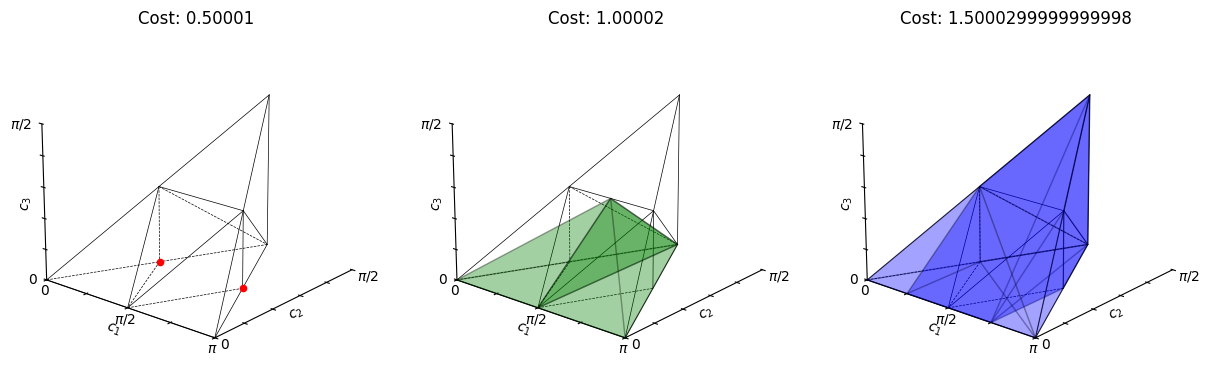

(np.float64(1.1049634169842018), np.float64(2.209882636315678), np.float64(2.209882636315678))


In [10]:
# NOTE if this coverage_set looks odd, it is likely due to setting COST_1Q >0
# this is a good idea for sorting equivalent cost sentences but prioritizing less total segments
# TODO reduce to isa coverage set to avoid this issue, prune more expensive + redundant circuit polytopes
# can use polytope.contains(polytope2) method?
# however, it will split up coverage_set into more pieces due to fine grained cost differences
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_costs(decomposer.isa.coverage_set))

In [11]:
logger.setLevel("INFO")
# N = 1_000
N = 25

# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

fidelities = []
all_timings = []
failures = 0

collected_failure_targets = []
collected_tooslow_targets = []

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-6:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1
        collected_failure_targets.append(u)

    finally:
        if decomposer.last_timing["numeric"] > 0.25:
            collected_tooslow_targets.append(u)

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

Decomposing random unitaries: 100%|██████████| 25/25 [00:02<00:00, 12.16it/s]


✔ Completed 25 successful runs (out of 25)
  → Failures: 0
  → Median Fidelity: 1.0000000000000007
  → Mean Fidelity:   0.9999999999999887
  → Min Fidelity:    0.9999999999997211

Average phase durations:
          lp: 0.0007 s
     numeric: 0.0784 s
      stitch: 0.0017 s

  Total average time: 0.0808 s


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

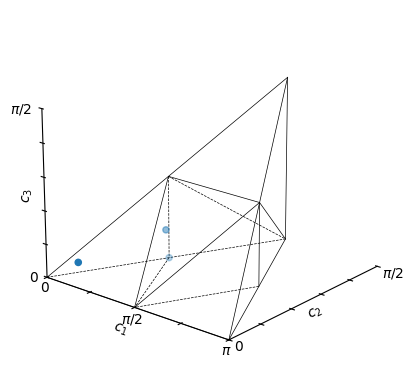

In [12]:
sentence_out, intermediates = decomposer._best_decomposition(
    GateInvariants.from_unitary(u)
)
scatter_plot(intermediates)

In [13]:
segment_sols = decomposer._numerics._synthesize_segments(
    sentence_out,
    intermediates,
)
segment_sols
params = segment_sols[0]
from qiskit.circuit.library import RVGate

u1 = RVGate(*params[:3])
u2 = RVGate(*params[3:6])

from qutip import tensor
import qutip as qt

u = tensor(qt.Qobj(u1.to_matrix()), qt.Qobj(u2.to_matrix()))
u = qt.Qobj(u, dims=[[4], [4]])
u

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.55930264-0.80484503j -0.13736713+0.02554256j -0.02138544-0.13794749j
  -0.01918133-0.00530162j]
 [ 0.13427457-0.03863277j -0.13998354+0.97005133j  0.01960223+0.00343267j
  -0.07845495+0.11546285j]
 [ 0.07845495+0.11546285j  0.01960223-0.00343267j -0.13998354-0.97005133j
  -0.13427457-0.03863277j]
 [-0.01918133+0.00530162j  0.02138544-0.13794749j  0.13736713+0.02554256j
  -0.55930264+0.80484503j]]

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

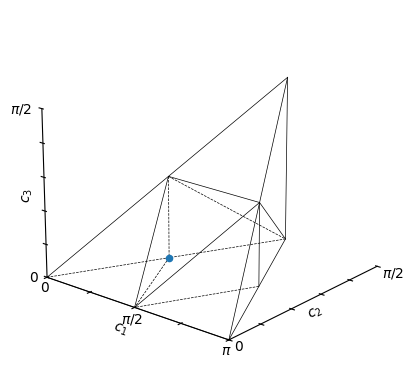

In [14]:
a1 = intermediates[0]
a1.plot()

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

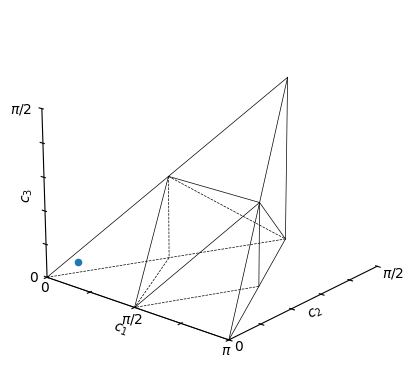

In [15]:
t = intermediates[1]
t.plot()

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [2:40:15<00:00, 480.77s/it]   


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

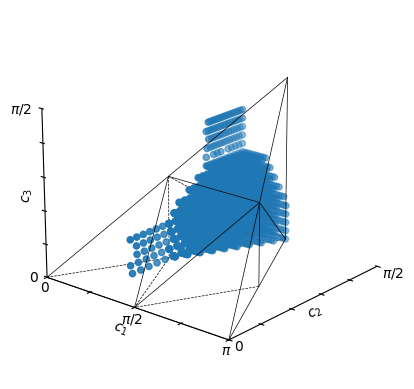

In [41]:
numerics = decomposer._numerics
success_gi = []
B = GateInvariants.from_weyl((0.5, 0.25, 0))
# Gi = GateInvariants.from_weyl((0.25, 0.25, 0))
for i in tqdm(np.linspace(0, 0.5, 20)):
    for j in np.linspace(i, 0.5, 20):
        for k in np.linspace(j, 0.25, 20):
            Gi = GateInvariants.from_weyl((k, j, i))
            numerics._synthesize_segments(gate_list=[Gi, B], invariant_list=[Gi, Gi])
            if numerics._segment_stats[0] > 0:
                success_gi.append(Gi)
scatter_plot(success_gi)

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

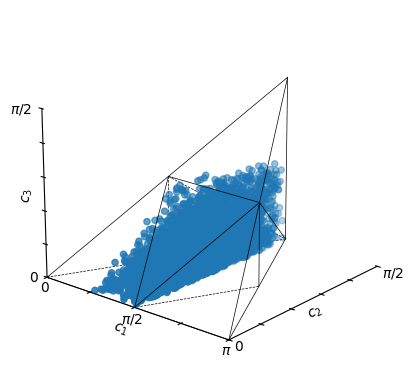

In [ ]:
# plot G.u.B, scatter for random choice u
invariant_list = []
G = iSwapGate().power(1 / 2)
for _ in range(5000):
    qc = QuantumCircuit(2)
    qc.append(G, [0, 1])
    qc.u(*np.random.rand(3) * np.pi, 0)
    qc.u(*np.random.rand(3) * np.pi, 1)
    qc.cx(0, 1)
    qc.csx(1, 0)
    invariant_list.append(GateInvariants.from_unitary(Operator(qc).data))
scatter_plot(invariant_list)

In [15]:
sandwich = qt.Qobj(a1.canonical_matrix) @ u @ qt.Qobj(a1.canonical_matrix)
GateInvariants.from_unitary(sandwich.full()).weyl

array([0.09002225, 0.04947687, 0.04054535])

In [66]:
def q_conj(U):
    MAGIC = np.array(
        [[1, 0, 0, 1j], [0, 1j, 1, 0], [0, 1j, -1, 0], [1, 0, 0, -1j]],
        dtype=np.cdouble,
    ) / np.sqrt(2)

    Um = MAGIC.conj().T.dot(U.dot(MAGIC))
    return Um

In [17]:
O = qt.Qobj(q_conj(sandwich.full()))
O

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-5.78483979e-01-2.76696734e-17j  7.94822904e-02+7.94822904e-02j
  -8.20114383e-02+8.20114383e-02j  7.99543410e-01-2.72733946e-17j]
 [ 5.43270670e-02+5.43270670e-02j -6.24500451e-17-1.20381303e-01j
   9.66618660e-01+6.93889390e-18j  1.50422484e-01+1.50422484e-01j]
 [ 3.94704341e-02-3.94704341e-02j -9.73483997e-01-6.93889390e-18j
  -6.24500451e-17+1.59585771e-01j  1.08962055e-01-1.08962055e-01j]
 [-8.10146650e-01-1.59124064e-18j -1.12255023e-01-1.12255023e-01j
   1.15604922e-01-1.15604922e-01j -5.40121310e-01-6.10863261e-17j]]

In [51]:
E = np.array(a1.logspec)
F = np.array(a1.logspec)
T = np.array(t.logspec)
DE = np.diag(E)
DF = np.diag(F)

In [52]:
DE = np.diag(np.exp(1j * np.pi * E))
DF = np.diag(np.exp(1j * np.pi * F))
DT = np.diag(np.exp(1j * np.pi * T))

In [18]:
sandwich = (
    qt.Qobj(q_conj(qt.Qobj(a1.canonical_matrix).full()))
    @ O
    @ qt.Qobj(q_conj(qt.Qobj(a1.canonical_matrix).full()))
    @ O.trans()
)
GateInvariants.from_unitary(sandwich.full()).logspec

(np.float64(0.07074459139802859),
 np.float64(0.0104339136462169),
 np.float64(-0.00930535780474454),
 np.float64(-0.07187314723950096))

In [73]:
qt.Qobj(q_conj(t.canonical_matrix))

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 9.91898537e-01+1.27032641e-01j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -1.37460832e-18-2.23711432e-17j]
 [ 0.00000000e+00+0.00000000e+00j  9.87944069e-01+1.54811227e-01j
   3.26043894e-17+2.29387985e-17j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  1.05991853e-17+1.10439362e-17j
   9.60274198e-01-2.79058174e-01j  0.00000000e+00+0.00000000e+00j]
 [ 2.94808865e-18+2.04158800e-19j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  1.00000000e+00+1.67519718e-17j]]

In [78]:
np.exp(2j * np.pi * np.array(t.logspec))

array([0.95206697+0.30588967j, 0.96772542+0.25200698j,
       1.        +0.j        , 0.84425307-0.53594473j])

In [75]:
(
    t.weyl[0] - t.weyl[1] + t.weyl[2],
    t.weyl[0] + t.weyl[1] - t.weyl[2],
    -(t.weyl[0] + t.weyl[1] + t.weyl[2]),
    -t.weyl[0] + t.weyl[1] + t.weyl[2],
)

(np.float64(0.08109059347668462),
 np.float64(0.09895386907208942),
 np.float64(-0.18004446254877404),
 np.float64(6.938893903907228e-18))

In [20]:
t.logspec, t.weyl, t.makhlin

((np.float64(0.049476934536044716),
  np.float64(0.04054529673834231),
  np.float64(-0.0),
  np.float64(-0.09002223127438702)),
 array([0.09002223, 0.04947693, 0.0405453 ]),
 [0.8854722690175116, 0.010328503265366855, 2.7640454555024028])

In [19]:
a1.logspec, a1.weyl, a1.makhlin

((np.float64(0.24999999999999997),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(-0.24999999999999997)),
 array([0.25, 0.25, 0.  ]),
 [0.25000000000000017, 0.0, 1.0000000000000004])

In [21]:
a1.logspec, a1.logspec, t.logspec

((np.float64(0.24999999999999997),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(-0.24999999999999997)),
 (np.float64(0.24999999999999997),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(-0.24999999999999997)),
 (np.float64(0.049476934536044716),
  np.float64(0.04054529673834231),
  np.float64(-0.0),
  np.float64(-0.09002223127438702)))

In [22]:
a1.logspec

(np.float64(0.24999999999999997),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(-0.24999999999999997))

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

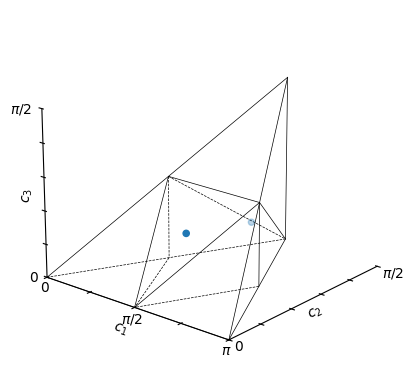

In [24]:
failed_gi = [GateInvariants.from_unitary(u) for u in collected_tooslow_targets]
from gulps.viz.invariant_viz import scatter_plot

scatter_plot(failed_gi)

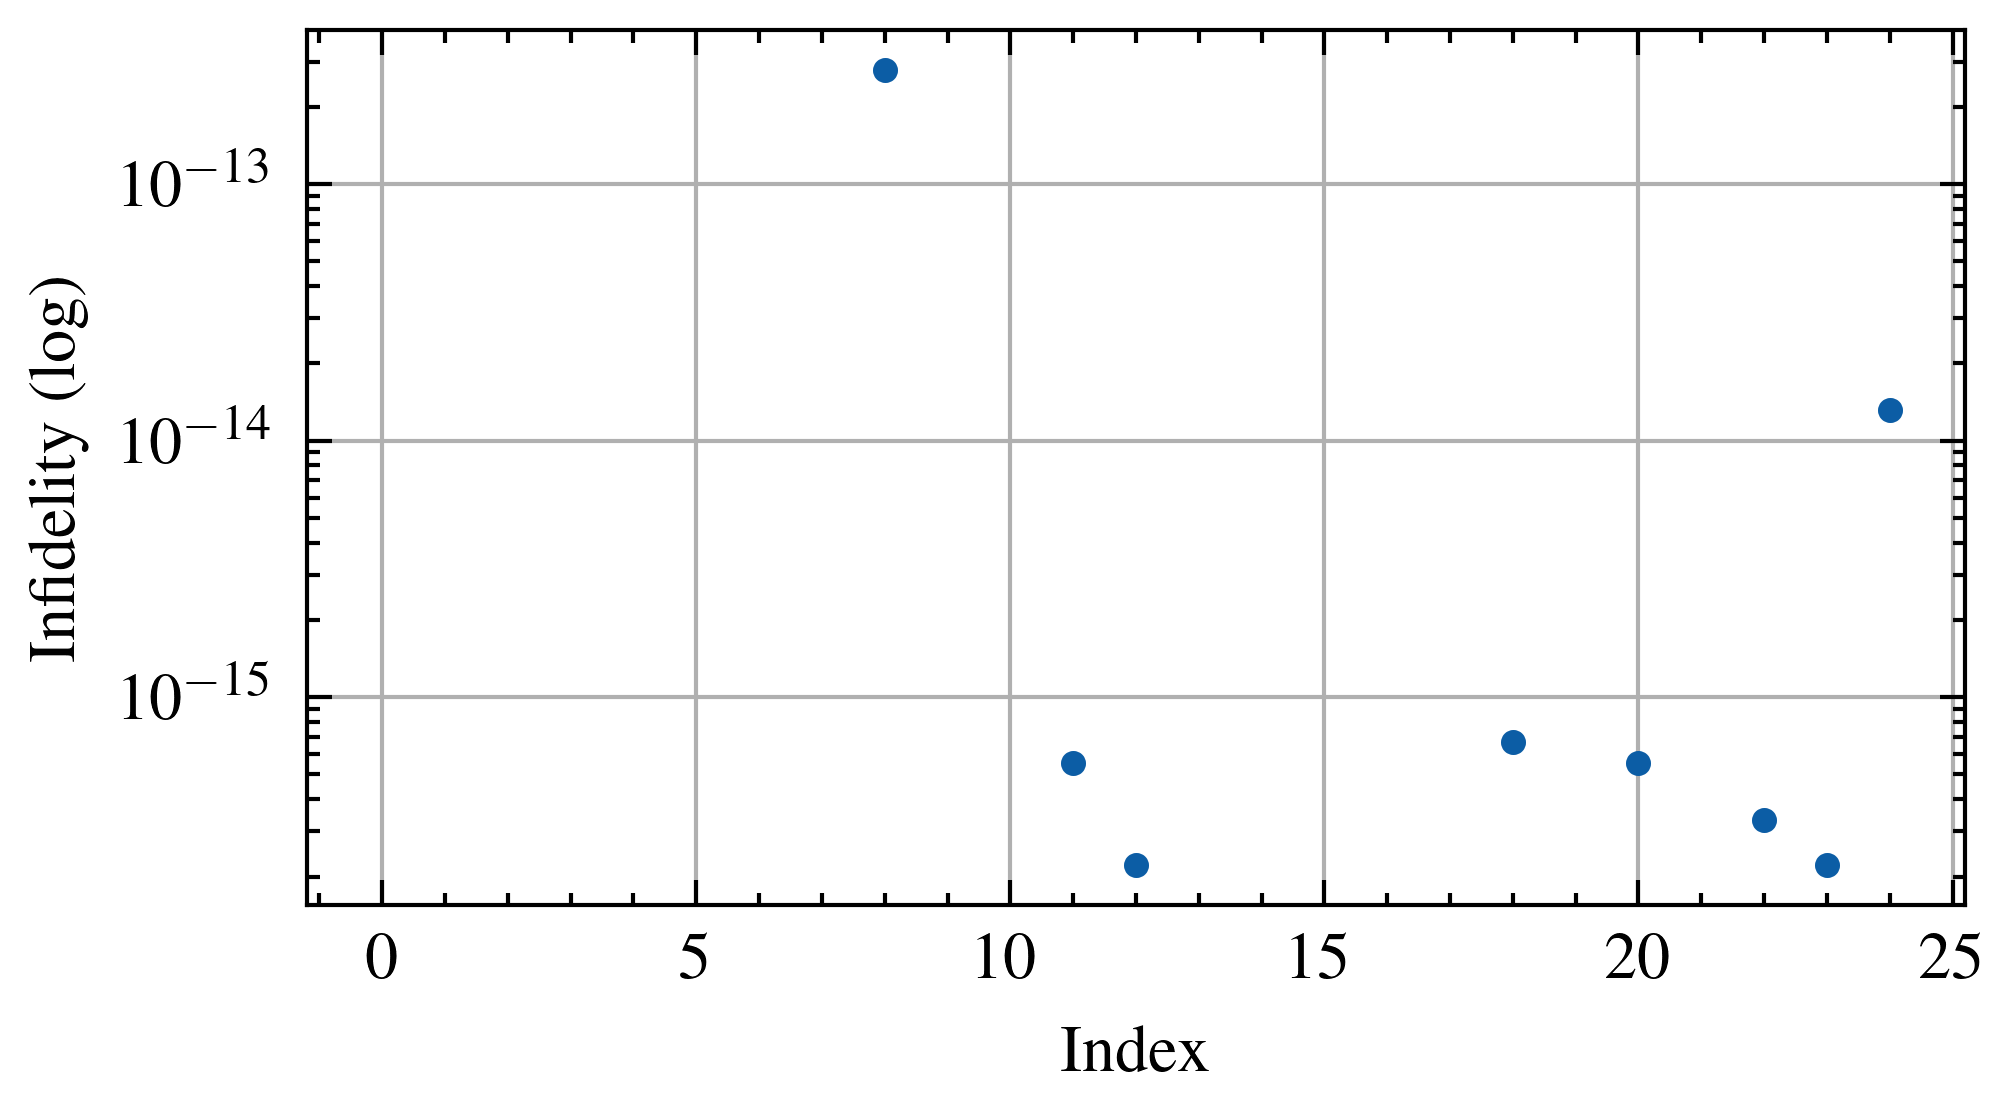

In [25]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

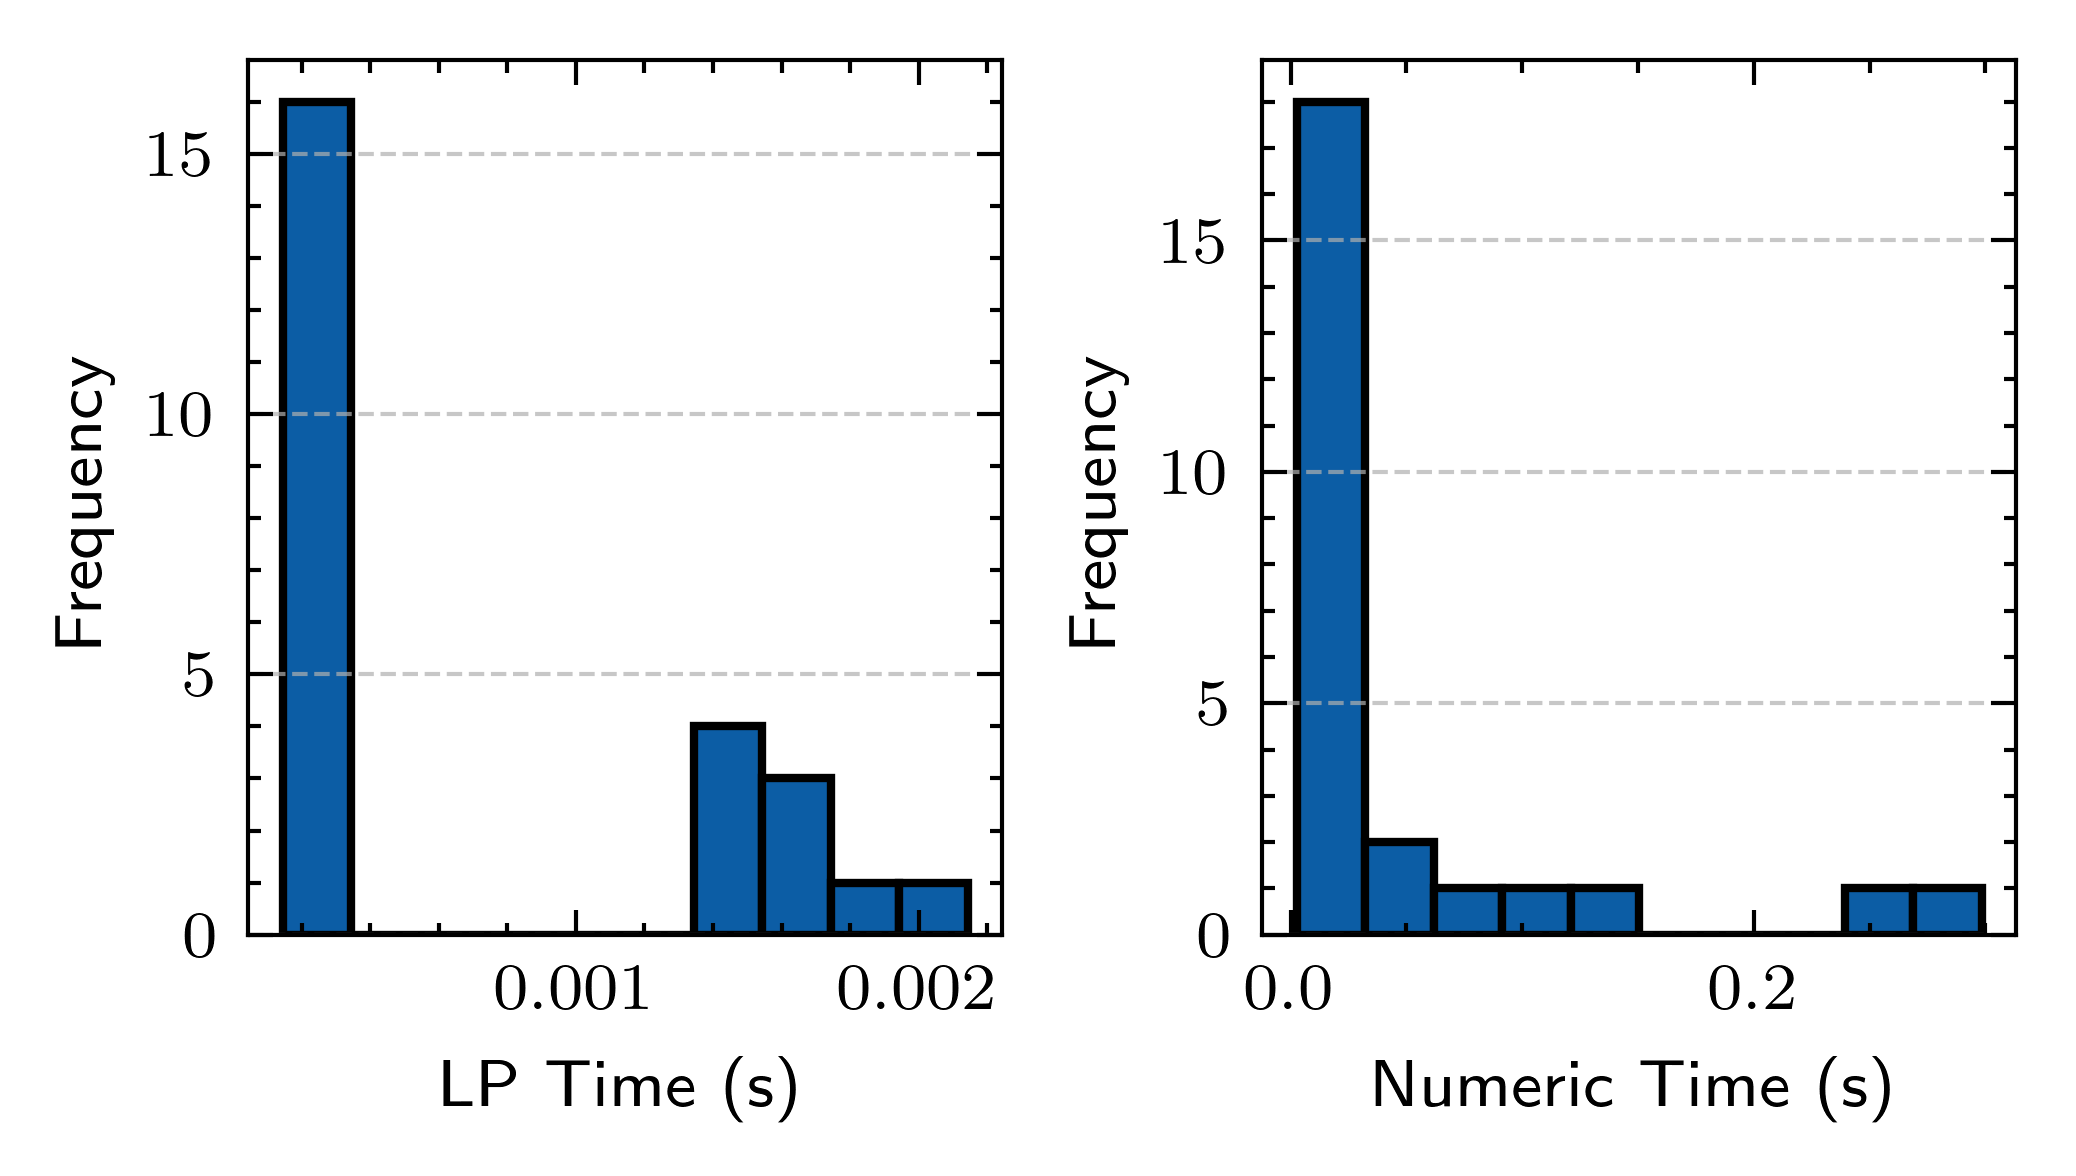

In [26]:
# Convert list of dicts to lists of values
lp_times = [d["lp"] for d in all_timings]
numeric_times = [d["numeric"] for d in all_timings]
stitch_times = [d["stitch"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()